## Damped driven oscillator

### Conditions for small displacements

The general governing equation for a damped driven harmonic oscillator is: $m\ddot{x} + \gamma \dot{x} + kx = e^{i\omega t}$

Simple, undamped harmonic motion, would just be standard oscillating behavior, e.g., a sin wave. So as described in the question, this would result in the governing equation to reduce to: $m\ddot{x} + kx = 0$

Consider a particle of mass $m$ moving in an arbitrary one-dimensional potential $V(x)$, with a minimum at $x = x_0$.

We can taylor-expand $V(x)$ about the minimum:

$$V(x) = V(x_0) + V'(x_0)(x - x_0) + \frac{1}{2}V''(x_0)(x - x_0)^2 + \frac{1}{6}V'''(x_0)(x - x_0)^3 + \cdots$$

At a minimum:
- $V'(x_0) = 0$ (stationary point),
- $V''(x_0) > 0$ (concave up — it's a minimum, not a maximum or inflection point).

#### Condition 1 — No damping

$${\gamma = 0}$$

Since we need it to be undamped, we need to set the damping factor to 0

#### Condition 2 — No external driving

$${F_{\text{ext}}(t) = 0}$$

There must be no time-dependent external force, which is the RHS of the equation, as this would result in a forced, not simple, harmonic oscillation

#### Condition 3 — Small displacements (linearisation)

$${|\xi| \ll \left|\frac{V''(x_0)}{V'''(x_0)}\right|}$$

The displacement must be small enough that the **cubic and higher-order terms** in the Taylor expansion are negligible compared to the quadratic term. This is the "small oscillation" approximation — it truncates the potential to a parabola.

#### Condition 4 — True minimum

$${V''(x_0) > 0}$$

The equilibrium point must be a **true minimum**, not a maximum or inflection point.

When all four conditions are satisfied, the equation of motion reduces to:

$$m\ddot{\xi} + V''(x_0)\,\xi = 0$$

with natural frequency:

$$\omega_0 = \sqrt{\frac{V''(x_0)}{m}} = \sqrt{\frac{k_{\text{eff}}}{m}}$$

## Homogenous solution

For the homogeous solution, we remove the external force term and set it to 0: 

$$m\ddot{x} + \gamma \dot{x} + kx = 0$$ 

We look for solutions of the form $x(t) = e^{rt}$, so we can write the characteristic equation:

$$mr^2 + \gamma r + k = 0$$

The solution for this characteristic equation becomes:

$$r = \frac{-\gamma \pm \sqrt{\gamma^2 - 4mk}}{2m}$$

For oscillators, it's usually common to express things in terms of the natural frequency and the damping factors, which are, respectively going to be defined as $\omega_0$ and $\beta$ as is common convention. 
$$\omega_0 = \sqrt{\frac{k}{m}},  \beta = \frac{\gamma}{2m} $$

When we solve for the roots above, we get three possible solutions taht depend on the relationship between \beta and \omega:
$$r = -\beta \pm \sqrt{\beta^2 - \omega_0^2}$$


There are always three modes for this type of problem, which are defined as critically dapned, overdamped and underdamped. Which of these regimes they fall into is based on the ratio of the above terms we just defined. 

### Critically damped
We set the descriminant term to 0, so $\beta = \omega_0$, i.e. $\gamma^2 = 4mk$

### Underdamped
In this case, the descriminant is negative and the roots are complex conjugates:
$${x(t) = e^{-\beta t}\bigl[A\cos(\omega_1 t) + B\sin(\omega_1 t)\bigr]}$$

or equivalently $x(t) = Ce^{-\beta t}\cos(\omega_1 t - \phi)$.


This implies that $\beta < \omega_0$, i.e. $\gamma^2 < 4mk$

### Overdamped
In this case, the descriminant is positive and the roots are real.

$${x(t) = Ae^{r_1 t} + Be^{r_2 t}}$$


This implies that $\beta > \omega_0$, i.e. $\gamma^2 > 4mk$



### Amplitude and Frequency relationship 
in the undriven case, there isn't going to be a relationship between amplitude and frequency. We know tha the frequency is fixed, and the amplitude is decaying due to the damping and stiffness. 

## Inhomogeneous problem
We need to assume an ansatz here, so the ansatz that is best for a oscillator is going to be:

$$x_p(t) = A(\omega)\,e^{i\omega t}$$


We can sub that into the overall governing equation and try to solve for A:
$$m(i\omega)^2 A\,e^{i\omega t} + \gamma(i\omega) A\,e^{i\omega t} + k\,A\,e^{i\omega t} = e^{i\omega t}$$

Therefore, we solve for A:
$${A(\omega) = \frac{1}{(k - m\omega^2) + i\gamma\omega}}$$

This is a complex amplitude, so it's going to have both real and complex terms - the magnitude will be real and the phase lag can be real as well, composed of the complex amplitude components.

We can now plot this for $m=1, k = 1, \gamma = 0.1$

In [30]:
import numpy as np
import plotly.graph_objs as go
from plotly.subplots import make_subplots

from matplotlib import cm
from matplotlib.colors import to_hex

viridis = cm.get_cmap("viridis", 5)
viridis_hex = [to_hex(viridis(i)) for i in range(viridis.N)]
c_mag = viridis_hex[3] 
c_phase = viridis_hex[1] 
c_peak = viridis_hex[4]  

m, k, gamma = 1.0, 1.0, 0.1
omega0 = np.sqrt(k / m)
beta = gamma / (2 * m)
Q = omega0 * m / gamma

omega = np.linspace(0.01, 2.5, 2000)

D = (k - m * omega**2) + 1j * gamma * omega
A = 1.0 / D

magnitude = np.abs(A)
phase_rad = -np.angle(A)
phase_deg = np.degrees(phase_rad)

# Mark the resonance peak
omega_res = np.sqrt(omega0**2 - 2 * beta**2)
A_peak = 1.0 / (gamma * np.sqrt(omega0**2 - beta**2))

fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    subplot_titles=(
        # rf"Particular Solution: Magnitude and Phase  ($m={m}$, $k={k}$, "
        rf"$\gamma={gamma}$, $Q={Q:.0f}$)",
        ""
    ),
    vertical_spacing=0.10
)

# Magnitude plot
fig.add_trace(
    go.Scatter(
        x=omega,
        y=magnitude,
        mode='lines',
        name='|A|',
        line=dict(color=c_mag)
    ),
    row=1, col=1
)

# Natural freq vertical line
fig.add_trace(
    go.Scatter(
        x=[omega0, omega0],
        y=[0.1, magnitude.max()],
        mode='lines',
        line=dict(color=viridis_hex[0], dash='dot', width=1),
        name=r'$\omega_0 = 1$',
        showlegend=True,
    ),
    row=1, col=1
)

# Resonance peak marker
fig.add_trace(
    go.Scatter(
        x=[omega_res], y=[A_peak],
        mode='markers',
        marker=dict(color=c_peak, size=10, symbol='circle'),
        name=f"Peak: |A| = {A_peak:.2f} at ω = {omega_res:.4f}"
    ),
    row=1, col=1
)

fig.update_yaxes(
    title_text=r'|A(ω)|', row=1, col=1, type='log', range=[np.log10(0.1), np.log10(magnitude.max()*1.1)]
)
fig.update_xaxes(showticklabels=False, row=1, col=1)
fig.update_yaxes(range=[-1, np.log10(magnitude.max())], row=1, col=1)

fig.add_trace(
    go.Scatter(
        x=omega,
        y=phase_deg,
        mode='lines',
        name='Phase lag (degrees)',
        line=dict(color=c_phase)
    ),
    row=2, col=1
)

fig.add_trace(
    go.Scatter(
        x=[omega.min(), omega.max()],
        y=[90, 90],
        mode='lines',
        line=dict(color=viridis_hex[0], dash='dot', width=1),
        name='90 deg phase',
        showlegend=False,
    ),
    row=2, col=1
)


fig.update_yaxes(
    title_text='phase lag (degrees)', row=2, col=1,
    tickvals=[0, 45, 90, 135, 180],
    range=[-5, 185]
)
fig.update_xaxes(
    title_text='driving freq', row=2, col=1,
    range=[omega.min(), omega.max()]
)

fig.update_layout(
    height=800,
    width=1000,
    showlegend=True,
    legend=dict(
        font=dict(size=11),
        x=0.02,
        y=0.99
    ),
    margin=dict(l=40, r=20, t=60, b=40),
    title=dict(text="Particular Solution: Magnitude and Phase (Bode plot)", x=0.5, xanchor='center')
)

# Show the plot in the notebook
fig.show()

print(f"Natural frequency = {omega0}")
print(f"Damping rate = {beta}")
print(f"Quality factor = {Q}")
print(f"Resonance frequency = {omega_res}")
print(f"Peak amplitude = {A_peak}")
print(f"Static amplitude = {1/k}")

/var/folders/37/mbm5qm1d03lg63qfy97k4tmw0000gn/T/ipykernel_2421/3881297126.py:8: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



Natural frequency = 1.0
Damping rate = 0.05
Quality factor = 10.0
Resonance frequency = 0.9974968671630001
Peak amplitude = 10.012523486435176
Static amplitude = 1.0


### Quality Factor

The quality factor is being defined as:

Driven oscillator: 
$$Q_{driven} = \frac{\omega_{center}}{\Delta \omega}$$

Undriven oscillator: 
$$Q_{undriven} = \frac{E_{oscillator}}{E_{lost,2\pi}}

We want to show that $$Q_{driven} = Q_{undriven}$$

If we start with the driven version, we first need to define the total energy, which is defined as the sum of hte potential and kneitc energy:
$$ E= \frac{1}{2}k\,|A|^2 + \frac{1}{2}m\omega^2|A|^2 = \frac{1}{2}(k + m\omega^2)\,|A(\omega)|^2$$

At small omega, the leading factor is $\omega_0$. Therefore:
$$|A(\omega)|^2 = \frac{1}{2}\,|A(\omega_0)|^2$$

Writing $\omega = \omega_0 + \delta$ with $|\delta| \ll \omega_0$ (small-damping / narrow-resonance regime):

$$k - m\omega^2 = m(\omega_0^2 - \omega^2) = -m(\omega + \omega_0)(\omega - \omega_0) \approx -2m\omega_0\,\delta$$

and $\gamma^2\omega^2 \approx \gamma^2\omega_0^2$. Substituting:

$$(2m\omega_0\,\delta)^2 + \gamma^2\omega_0^2 = 2\gamma^2\omega_0^2$$

$$4m^2\omega_0^2\,\delta^2 = \gamma^2\omega_0^2$$

$$\delta = \pm\frac{\gamma}{2m}$$

Solving for A, then gives us:

$$\Delta\omega = 2|\delta| = \frac{\gamma}{m}$$


or the undriven, underdamped oscillator the solution is:

$$x(t) = C\,e^{-\beta t}\cos(\omega_1 t - \phi), \qquad \beta = \frac{\gamma}{2m},\quad \omega_1 = \sqrt{\omega_0^2 - \beta^2}$$

The total energy (averaged over one cycle) decays as:

$$E(t) = E_0\,e^{-2\beta t} = E_0\,e^{-\gamma t/m}$$

 In one radian of oscillation $\Delta t = 1/\omega_1$:

$$-\Delta E = E(t) - E\!\left(t + \frac{1}{\omega_1}\right) \approx E(t)\cdot\frac{2\beta}{\omega_1}$$

where we used $e^{-2\beta/\omega_1}$$

The second definition of Q is:

$$Q_{undriven} = \frac{E}{|\Delta E|/\text{radian}} = \frac{E(t)}{E(t)\cdot 2\beta/\omega_1} = \frac{\omega_1}{2\beta}$$

For small damping, $\omega_1 = \sqrt{\omega_0^2 - \beta^2} \approx \omega_0$, so:

$${Q_{driven} = \frac{\omega_1}{2\beta} \approx \frac{\omega_0}{2\beta} = \frac{m\omega_0}{\gamma} = Q_1}$$

$${Q_{driven} = \frac{\omega_0}{\Delta\omega} = \frac{m\omega_0}{\gamma} = \frac{\omega_1}{2\beta} \approx Q_{undriven} \qquad (\text{for } \beta \ll \omega_0)}$$

The equivalence holds in the small-damping limit, where $\omega_1 \approx \omega_0$ and the resonance curve is narrow enough that our linearisation around $\omega_0$ is valid.

The amplitude of the undriven oscillator decays as $e^{-\beta t}$. The $1/e$ decay time for the **amplitude** is:

$$\tau = \frac{1}{\beta} = \frac{2m}{\gamma}$$

From the Q factor:

$$Q = \frac{\omega_0}{2\beta} \qquad  

\qquad \beta = \frac{\omega_0}{2Q} = \frac{\pi f_0}{Q}$$

so:

$$\tau = \frac{1}{\beta} = \frac{Q}{\pi f_0}$$

$f_0 = 100\,\text{Hz}$ and $Q = 10^9$:

$$\tau = \frac{10^9}{\pi \times 100} $$

### Lowest-order correction to simple undamped unforced harmonic motion

We need to assume here that the potential is not perfectly parabolic, and that there is something aharmonic that we need to be correcting for. 

We can assume that the potential is defined as:

$$V(x) = D(1-e^{-\alpha(x-x_0)})^2$$

And then we can take the Taylor series expansion of this about the minimum to find the coefficients of the expansion. 

$$V(x) = V(x_0) + V'(x_0)(x-x_0) + \frac{V''(x_0)}{2}(x-x_0)^2 + \frac{V'''(x_0)}{6}(x-x_0)^3 + \frac{V''''(x_0)}{24}(x-x_0)^4$$


Based on that, we can then find the coefficients of the expansion:

$$V''(x_0) = 2D\alpha^2$$

$$V'''(x_0) = -6D\alpha^3$$

$$V''''(x_0) = 24D\alpha^4$$

We can simplify this to:

$$V(x) = \frac{1}{2}kx^2 + \beta x^3$$ 
where we assume $\beta$ is the constant that cleans up the equation with $\beta = \frac{1}{6}V'''(0)$



From $V(\xi) = \frac{1}{2}k\xi^2 + \beta\xi^3$ the equation of motion is:

$$\ddot{\xi} + \omega_0^2\,\xi = -\frac{3\beta}{m}\,\xi^2$$

Write $\xi = \xi_0 + \xi_1$ with $\xi_0 \sim O(a)$, $\xi_1 \sim O(a^2)$. At zeroth order: $\xi_0 = a\cos(\omega_0 t)$.

Substituting into the RHS and using $\cos^2\theta = \frac{1}{2}(1 + \cos 2\theta)$:

$$\ddot{\xi}_1 + \omega_0^2\,\xi_1 = -\frac{3\beta a^2}{2m}\left(1 + \cos 2\omega_0 t\right)$$

This is a forced oscillator at frequencies 0 and $2\omega_0$.

We can solve this for $x(t)$:

$$\xi_1(t) = -\frac{3\beta a^2}{2k} + \frac{\beta a^2}{2k}\cos(2\omega_0 t) = -\frac{V'''(x_0)\,a^2}{4k}\left(1 - \tfrac{1}{3}\cos 2\omega_0 t\right)$$

The correction has two effects: DC offset (the mean position shifts away from $x_0$ — this is the origin of thermal expansion), and a second harmonic that distorts the waveform. The frequency remains $\omega_0$ at this order; a frequency shift enters at $O(a^2)$

In [34]:
import numpy as np
import plotly.graph_objs as go
from plotly.subplots import make_subplots
from scipy.integrate import solve_ivp

D, alpha_morse, x0 = 5.0, 1.5, 0.0
V = lambda x: D * (1 - np.exp(-alpha_morse * (x - x0)))**2

k_val     = 2 * D * alpha_morse**2                  # V''(x0)
alpha_val = -6 * D * alpha_morse**3                 # V'''(x0)  (cubic)
mu_val    = 24 * D * alpha_morse**4 - 12*D*alpha_morse**4  # V''''(x0) (quartic)
dx = 1e-5
V3 = (V(x0+2*dx) - 2*V(x0+dx) + 2*V(x0-dx) - V(x0-2*dx)) / (2*dx**3)
V4 = (V(x0+2*dx) - 4*V(x0+dx) + 6*V(x0) - 4*V(x0-dx) + V(x0-2*dx)) / dx**4
alpha_val = V3
mu_val = V4

m = 1.0
omega0 = np.sqrt(k_val / m)

print(f"k   = V''(x0)   = {k_val:.4f}")
print(f"α   = V'''(x0)  = {alpha_val:.4f}")
print(f"μ   = V''''(x0) = {mu_val:.4f}")
print(f"ω₀  = {omega0:.4f}")

a = 0.4

def xi_perturbative(t, a):
    xi1 = a * np.cos(omega0 * t)
    xi2 = -(alpha_val * a**2) / (4 * k_val) * (
        1 - (1/3) * np.cos(2 * omega0 * t))
    return xi1 + xi2
def ode(t, y):
    xi, v = y
    dV = (V(xi + 1e-8) - V(xi - 1e-8)) / (2e-8)
    return [v, -dV / m]

t_span = (0, 25)
t_eval = np.linspace(*t_span, 3000)

sol = solve_ivp(ode, t_span, [a, 0], t_eval=t_eval, rtol=1e-12, atol=1e-14)
xi_exact = sol.y[0]
xi_pert  = xi_perturbative(sol.t, a)
xi_shm   = a * np.cos(omega0 * sol.t)

# === Plotly Plots ===
fig = make_subplots(
    rows=2, cols=1, shared_xaxes=True,
    subplot_titles=(f"Anharmonic Correction (Morse potential, a = {a})", "Residuals"),
    vertical_spacing=0.1
)
fig.add_trace(go.Scatter(
    x=sol.t, y=xi_exact, mode='lines',
    name='Exact (numerical)', line=dict(color='blue', width=2)
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=sol.t, y=xi_pert, mode='lines',
    name='SHM + lowest-order correction', line=dict(color='red', dash='dash', width=2)
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=sol.t, y=xi_shm, mode='lines',
    name='Pure SHM', line=dict(color='green', dash='dot', width=1.5), opacity=0.7
), row=1, col=1)

fig.update_yaxes(title_text=r'$\xi(t)$', row=1, col=1)

# Bottom: residuals
fig.add_trace(go.Scatter(
    x=sol.t, y=xi_exact - xi_shm, mode='lines',
    name='Exact − SHM', line=dict(color='green', width=1.5)
), row=2, col=1)

fig.add_trace(go.Scatter(
    x=sol.t, y=xi_exact - xi_pert, mode='lines',
    name='Exact − (SHM + correction)', line=dict(color='red', width=1.5)
), row=2, col=1)

fig.update_xaxes(title_text='t', row=2, col=1)
fig.update_yaxes(title_text='Residual', row=2, col=1)

fig.update_layout(
    height=700,
    width=900,
    legend=dict(font=dict(size=12)),
    margin=dict(l=50, r=50, t=60, b=50),
    showlegend=True,
    title_font_size=18,
    font=dict(size=13)
)

fig.show()

k   = V''(x0)   = 22.5000
α   = V'''(x0)  = -101.2500
μ   = V''''(x0) = 355.0458
ω₀  = 4.7434


## Normal modes of two damped oscillators

When we have two coupled systems, we can model them as a system of equations in a matrix form:
$$\bold{M\ddot{x}} + \bold{Kx} = 0$$

where x constitutes the vector of solutions for both oscillators. 

For the coupled system, we are given that $m_1 = m_2 = m$ and $k_1 = k_2 = k$

This simplifies our matrix terms into:

$$ M = 
\begin{bmatrix}
m & 0 \\
0 & m
\end{bmatrix}
,
K = 
\begin{bmatrix}
k+k_{const} & -k \\
-k &k+k_{const}
\end{bmatrix}
$$

All we need to do is find the eigenvalues and eigenvectors of this to build the diagonal matrix composed of normal modes. We again use an Ansatz/assumed solution of $$x(t) = v * e^{i \omega t}$$

Our system of equations is:
$$\bold{M\ddot{x}} + \bold{K\dot{x}} =  
\begin{bmatrix}
m & 0 \\
0 & m
\end{bmatrix} * 
\begin{bmatrix}
-\omega^2 \\
-\omega^2
\end{bmatrix} * \bold{x(t)}
 +
\begin{bmatrix}
k+k_{const} & -k \\
-k &k+k_{const}
\end{bmatrix}* \bold{x(t)}$$

Therefore, the eigenvalue quadtradic equation becomes:

$$(k+k_{const} - m \omega^2)^2 - k_{const}^2 = 0$$

Therefore, the solutions for $\omega$ become:
$$\omega_1 = \sqrt{\frac{k}{m}}, \omega_2 = \sqrt{\frac{k+2k_{const}}{m}}$$


We sub these into the determinant equation:
$$ (\bold{K} - \omega^2 * \bold{M}) \bold{v} = 0 $$

For $\omega_1$: 

$$\begin{bmatrix}
k_{const} & -k_{const} \\
-k_{const} &k_{const}
\end{bmatrix}* 
\begin{bmatrix}
v_1 \\
v_2
\end{bmatrix} = 0$$ 

For $\omega_2$: 

$$\begin{bmatrix}
-k_{const} & -k_{const} \\
-k_{const} & -k_{const}
\end{bmatrix}* 
\begin{bmatrix}
v_1 \\
v_2
\end{bmatrix} = 0$$ 


Therefore:
$$ \bold{v_1} = \begin{bmatrix}
1 \\
1
\end{bmatrix}
, 
 \bold{v_2} = \begin{bmatrix}
1 \\
-1
\end{bmatrix}

We can then write out the diagnoal matrix with this:

$$\bold{M} = \begin{bmatrix}
v_1 \\
v_2
\end{bmatrix}$$

$$ \bold{A} * \bold{M} = \bold{A} * \begin{bmatrix}
v_1 \\
v_2
\end{bmatrix} =\begin{bmatrix}
v_1 \\
v_2
\end{bmatrix} *  \begin{bmatrix}
\lambda_1 & 0 \\
0 & \lambda_2
\end{bmatrix} = \bold{M} * \bold{D} 

#### Decoupling into normal coordinates

Define normal coordinates using the modal matrix $P = [\mathbf{v}_1 \mid \mathbf{v}_2]$:

$$\mathbf{x} = P\,\mathbf{q}, \qquad P = \begin{bmatrix} 1 & 1 \\ 1 & -1 \end{bmatrix}, \qquad \mathbf{q} = \begin{bmatrix} q_1 \\ q_2 \end{bmatrix}$$

We can then sub $\mathbf{x} = P\mathbf{q}$ into $M\ddot{\mathbf{x}} + K\mathbf{x} = 0$ and left-multiplying by $P^T$

Since $M = mI$ and the eigenvectors are orthogonal, both products are diagonal:

$$\tilde{M} = P^T M P = 2m\,I, \qquad \tilde{K} = P^T K P = \begin{bmatrix} 2k & 0 \\ 0 & 2(k + 2k_c) \end{bmatrix}$$

The system decouples into two independent oscillators:

$$\ddot{q}_1 + \omega_1^2\,q_1 = 0, \qquad \ddot{q}_2 + \omega_2^2\,q_2 = 0$$

where $q_1 = \frac{1}{2}(x_1 + x_2)$ is the centre-of-mass mode (both masses move in phase) and $q_2 = \frac{1}{2}(x_1 - x_2)$ is the relative mode (masses move in antiphase). The general solution is:

$$\mathbf{x}(t) = P\mathbf{q}(t) = \begin{bmatrix} 1 \\ 1 \end{bmatrix}(A_1\cos\omega_1 t + B_1\sin\omega_1 t) + \begin{bmatrix} 1 \\ -1 \end{bmatrix}(A_2\cos\omega_2 t + B_2\sin\omega_2 t)$$

### Also checked with sympy!

In [ ]:
import sympy as sp
m, k, kc, omega = sp.symbols('m k k_c omega', real=True, positive=True)
K = sp.Matrix([[k + kc, -kc], 
               [-kc, k + kc]])
M = sp.Matrix([[m, 0], 
               [0, m]])
char_matrix = K - (omega**2) * M
det_eq = char_matrix.det()
solutions = sp.solve(det_eq, omega**2)

print("Analytical Eigenvalues (omega^2):")
for i, sol in enumerate(solutions):
    print(f"Mode {i+1}: {sol}")

eigenvectors = char_matrix.subs(omega**2, solutions[0]).nullspace()
print(f"\nExample Eigenvector for Mode 1: {eigenvectors[0]}")

Analytical Eigenvalues (omega^2):
Mode 1: k/m
Mode 2: (k + 2*k_c)/m

Example Eigenvector for Mode 1: Matrix([[1], [1]])


In [ ]:
import numpy as np
from numpy.linalg import eig

m = 1.0
k = 2.0
kc = 0.5
M = np.array([[m, 0], 
              [0, m]])

K = np.array([[k + kc, -kc], 
              [-kc, k + kc]])


A = np.linalg.inv(M) @ K
eigenvalues, eigenvectors = eig(A)
frequencies = np.sqrt(eigenvalues)

print(f"Matrix A:\n{A}")
print(f"\nEigenvalues (omega^2): {eigenvalues}")
print(f"Normal Mode Frequencies (omega): {frequencies}")
print(f"\nEigenvectors (Normal Modes):\n{eigenvectors}")

Matrix A:
[[ 2.5 -0.5]
 [-0.5  2.5]]

Eigenvalues (omega^2): [3. 2.]
Normal Mode Frequencies (omega): [1.73205081 1.41421356]

Eigenvectors (Normal Modes):
[[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]]


In [ ]:
#model two coupled springs visually 

## Digital filter

The digital filter used for smoothing is:

$$y(k) = \alpha y (k-1) + (1- \alpha) x(k)$$

This is a difference equation, so we need to solve it using recursive expansion. The general solution is something of the form:

$$ y_g = \sum_{n=1}^{N} C_n r^k_n$$

Therefore for this problem, the closed form solution becomes:

$$y(k) = (1- \alpha) \sum \alpha^n x(k-n)$$

Then, we can use a z-transform next to solve this, since it is of the smae shape as a one sided z transform. 
We'll set $y(k-1) \to z^-1 Y(z)$

The transfer function is:
$$H(z) = \frac{Y(z)}{X(z)} = \frac{1-\alpha}{1-\alpha z^{-1}}$$

Using all these elements, we can find the frequency response of the digital filter:

$$y(k) = \lim_{k \to \inf} \sum_{n=0}^{k}h(n)x(k-n)$$



In [39]:
import numpy as np
import matplotlib.pyplot as plt

import plotly.graph_objects as go

def plot_frequency_response(alphas):
    w = np.linspace(0, np.pi, 500)
    fig = go.Figure()
    for alpha in alphas:
        num = 1 - alpha
        den = np.sqrt(1 + alpha ** 2 - 2 * alpha * np.cos(w))
        h_amplitude = num / den
        fig.add_trace(go.Scatter(
            x=w / np.pi,
            y=h_amplitude,
            mode='lines',
            name=f'alpha = {alpha}'
        ))
    fig.update_layout(
        title="Frequency Response of Exponential Smoothing Filter",
        xaxis_title="Normalized Frequency",
        yaxis_title="Gain",
        legend_title="Alpha",
        template="plotly_white"
    )
    fig.show()

plot_frequency_response([0.2, 0.4, 0.7, 0.95, 0.98])

In [14]:
import numpy as np
from IPython.display import Audio, display

fs = 8000
duration = 2.0
t = np.linspace(0, duration, int(fs * duration), endpoint=False)

clean_signal = 0.5 * np.sin(2 * np.pi * 440 * t)

noise = 0.2 * np.random.normal(0, 1, len(t))
x = clean_signal + noise
def apply_filter(signal, alpha):
    y = np.zeros_like(signal)
    for k in range(1, len(signal)):
        y[k] = alpha * y[k-1] + (1 - alpha) * signal[k]
    return y

y = apply_filter(x, alpha=0.9)
print("Noisy Signal (x):")
display(Audio(x, rate=fs))

print("Filtered Signal (y):")
display(Audio(y, rate=fs))

Noisy Signal (x):


Filtered Signal (y):


## Drumhead modes

Intuitively, I would think that a drumhead would be defined by a circular wave equation, and so the modes would be defined based off of the inverse of the radius. The wave function in plar coordinates is defined as:

$$\nabla^2 u = \frac{\partial^2 u}{\partial r^2} + \frac{1}{r}\frac{\partial u}{\partial r} + \frac{1}{r^2}\frac{\partial^2 u}{\partial \theta^2}$$

We can use the separate of variables method and set:

$$u(r, \theta, t) = R(r)\,\Theta(\theta)\,\mathcal{T}(t)$$


Substitute $u = R(r)\,\Theta(\theta)\,\mathcal{T}(t)$ into the wave equation:

$$R\,\Theta\,\mathcal{T}'' = c^2\left(R''\Theta\mathcal{T} + \frac{1}{r}R'\Theta\mathcal{T} + \frac{1}{r^2}R\,\Theta''\mathcal{T}\right)$$

Divide everything by $R\,\Theta\,\mathcal{T}$:

$$\frac{\mathcal{T}''}{\mathcal{T}} = c^2\left(\frac{R''}{R} + \frac{1}{r}\frac{R'}{R} + \frac{1}{r^2}\frac{\Theta''}{\Theta}\right)$$




Therefore, we get that:
$$\mathcal{T}''(t) + \omega^2\,\mathcal{T}(t) = 0$$

and that becomes $\mathcal{T}(t) = e^{\pm i\omega t}$

on the other side of the equation, we have the spatial component changing:
$$c^2\left(\frac{R''}{R} + \frac{1}{r}\frac{R'}{R} + \frac{1}{r^2}\frac{\Theta''}{\Theta}\right) = -\omega^2$$


We can then rearrange to be able to separate out $\theta$ from $\r$:
$$r^2\frac{R''}{R} + r\frac{R'}{R} + \frac{\omega^2 r^2}{c^2} = -\frac{\Theta''}{\Theta}$$

which means that we now have the LHS depend on ly on r and the RHS depend only on \theta.

$${\Theta''(\theta) + m^2\,\Theta(\theta) = 0}$$

We can therefore use the constant $m^2$ (we are using that so we can nicely slot into the bessel equation):
$\Theta(\theta) = e^{\pm im\theta}$, or $C\cos(m\theta) + D\sin(m\theta)$.

This allows us to use the general form of the bessl equation:
$$r^2 R'' + r R' + (k^2 r^2 - m^2)R = 0$$

Bessel's equation is a second-order ODE, so it has two linearly independent solutions**:

1. $J_m(kr)$ which is finite at $r = 0$
2. $Y_m(kr)$ which diverges as $r \to 0$

The centre of the drum ($r = 0$) is a physical point — the displacement must be finite there. Since $Y_m(kr) \to -\infty$ as $r \to 0$, we must discard it.

$${R(r) = J_m(kr)}$$

To find the **six lowest** modes, we collect all the zeros $j_{mn}$ (for various $m$ and $n$) and sort them in ascending order — since $f \propto j_{mn}$, the smallest zeros give the lowest frequencies.

Therefore, when we analytically solve for this, the normal modes are:

$${u_{mn}(r, \theta, t) = J_m\!\left(\frac{j_{mn}\,r}{L}\right)\left[C\cos(m\theta) + D\sin(m\theta)\right]\cos(\omega_{mn} t - \phi)}$$

The spatial pattern is:

$$\Phi_{mn}(r, \theta) = J_m\!\left(\frac{j_{mn}\,r}{L}\right)\cos(m\theta)$$

## Trying to plot the drum modes

<>:37: SyntaxWarning:

invalid escape sequence '\l'

<>:37: SyntaxWarning:

invalid escape sequence '\l'

/var/folders/37/mbm5qm1d03lg63qfy97k4tmw0000gn/T/ipykernel_2421/1261420996.py:37: SyntaxWarning:

invalid escape sequence '\l'



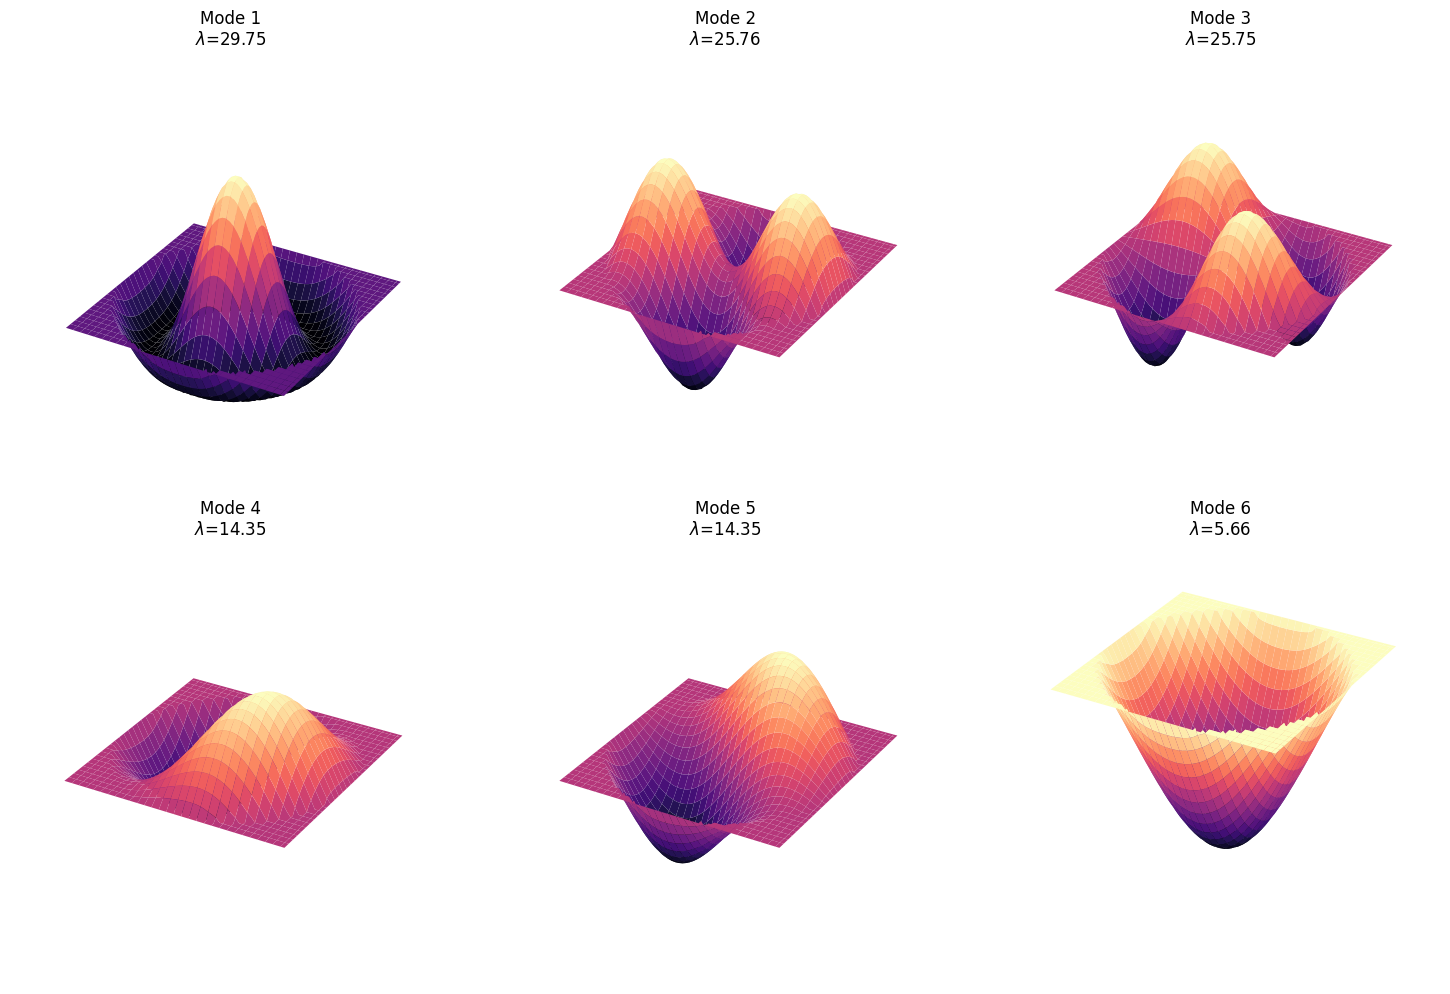

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import dok_matrix
from scipy.sparse.linalg import eigsh

def solve_drum_modes(N=60):
    L = 1.0
    x = np.linspace(-L, L, N)
    y = np.linspace(-L, L, N)
    X, Y = np.meshgrid(x, y)
    dist_sq = X**2 + Y**2
    inside_mask = dist_sq <= L**2
    indices = np.where(inside_mask.ravel())[0]
    id_map = {idx: i for i, idx in enumerate(indices)} 
    num_pts = len(indices)
    h = x[1] - x[0]
    A = dok_matrix((num_pts, num_pts))
    for i in range(N):
        for j in range(N):
            flat_idx = i * N + j
            if inside_mask[i, j]:
                row = id_map[flat_idx]
                A[row, row] = -4 / h**2
                for di, dj in [(-1,0), (1,0), (0,-1), (0,1)]:
                    ni, nj = i + di, j + dj
                    n_flat = ni * N + nj
                    if 0 <= ni < N and 0 <= nj < N and inside_mask[ni, nj]:
                        col = id_map[n_flat]
                        A[row, col] = 1 / h**2             
    vals, vecs = eigsh(A, k=6, which='SM')
    fig = plt.figure(figsize=(15, 10))
    for i in range(6):
        mode_grid = np.zeros((N, N))
        mode_grid[inside_mask] = vecs[:, i]
        ax = fig.add_subplot(2, 3, i+1, projection='3d')
        ax.plot_surface(X, Y, mode_grid, cmap='magma', edgecolor='none')
        ax.set_title(f"Mode {i+1}\n$\lambda$={-vals[i]:.2f}")
        ax.set_axis_off()
    plt.tight_layout()
    plt.show()

solve_drum_modes()

### Asking an LLM what the best way to plot this problem is - my above solution and sparse grid was too course and shows the wrong modes!

(and of course, scipy saves the day )

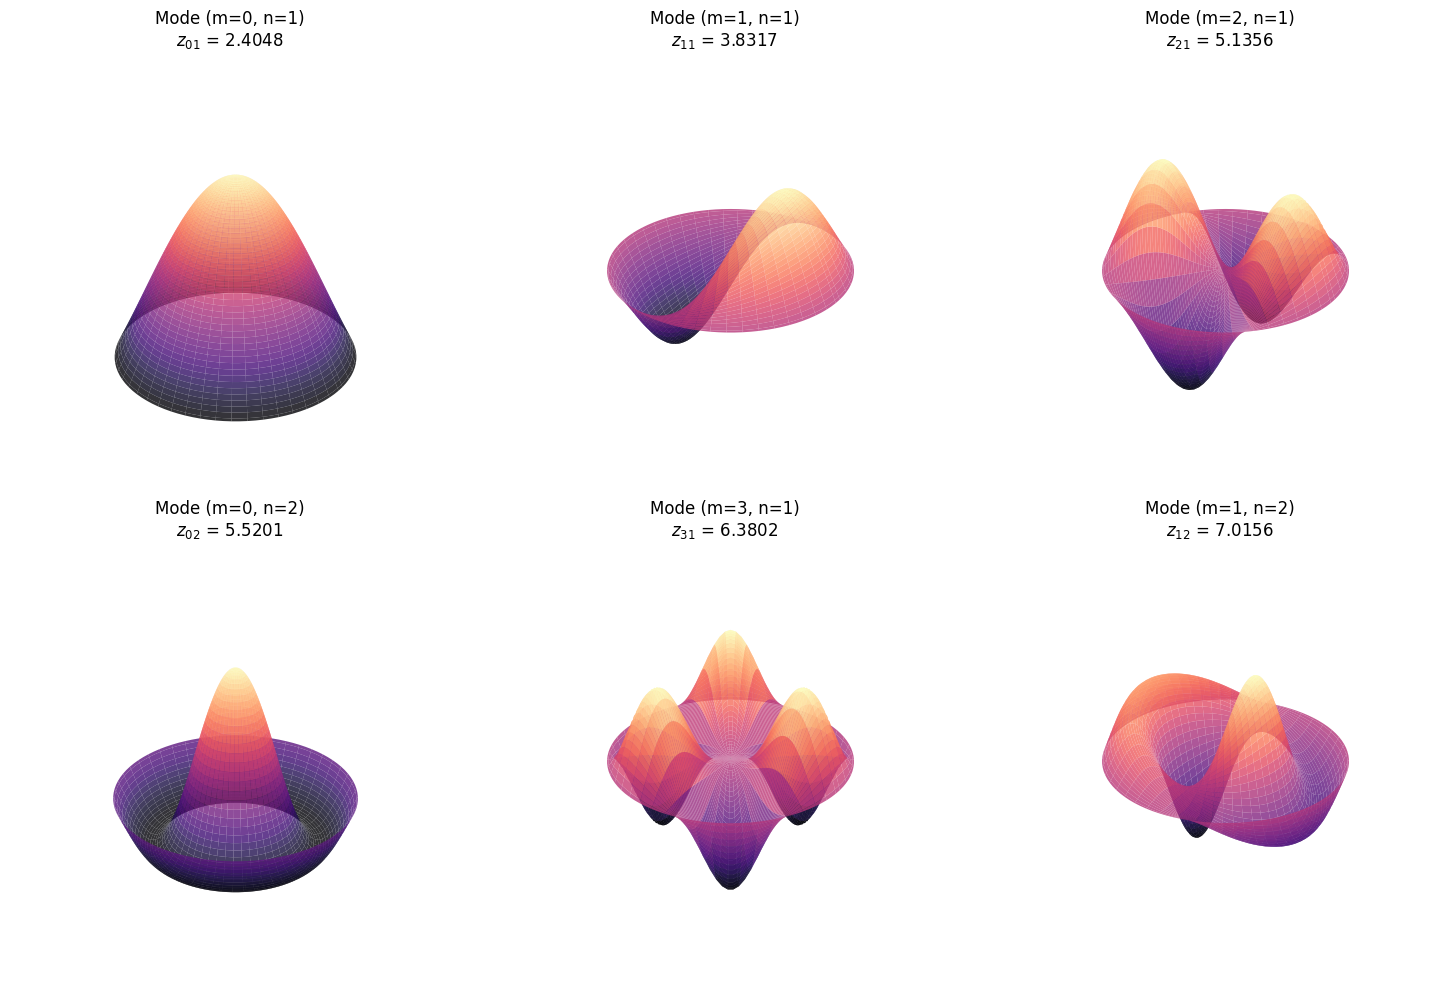

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jn, jn_zeros

def plot_drums():
    r = np.linspace(0, 1, 100)
    theta = np.linspace(0, 2*np.pi, 100)
    R, Theta = np.meshgrid(r, theta)
    X, Y = R*np.cos(Theta), R*np.sin(Theta)
    modes = [(0, 1), (1, 1), (2, 1), (0, 2), (3, 1), (1, 2)]
    fig = plt.figure(figsize=(15, 10))
    for i, (m, n) in enumerate(modes):
        z_mn = jn_zeros(m, n)[n-1]
        Z = jn(m, z_mn * R) * np.cos(m * Theta)
        ax = fig.add_subplot(2, 3, i+1, projection='3d')
        ax.plot_surface(X, Y, Z, cmap='magma', edgecolor='none', alpha=0.8)
        ax.set_title(f"Mode (m={m}, n={n})\n$z_{{{m}{n}}}$ = {z_mn:.4f}")
        ax.set_axis_off()

    plt.tight_layout()
    plt.show()

plot_drums()